# IMPLEMENT VISION TRANSFORMER FOR IMAGE CLASSIFICATION

## STEP 1: Import necessary libraries

### 1.1. Clone repository

In [3]:
import os
import shutil

# Remove existing folder if it exists
if os.path.exists('DL_self_practice'):
    shutil.rmtree('DL_self_practice')

# Clone repository
!git clone https://github.com/ArrayPowerPlay/DL_self_practice.git

Cloning into 'DL_self_practice'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 35 (delta 2), reused 12 (delta 0), pack-reused 20 (from 1)
Receiving objects: 100% (35/35), 463.29 KiB | 3.46 MiB/s, done.
Resolving deltas: 100% (7/7), done.


### 1.2. Import libraries

In [4]:
import os 
os.chdir('DL_self_practice')
import torch
from utils import spy

## STEP 2: Train ViT model

### 2.1. Train ViT model on FashionMNIST dataset 

Fashion MNIST is an MNIST-like dataset of 70,000 28x28 grayscale fashion image, associated with a label from 10 classes
- Training set: 60,000 examples
- Test set: 10,000 examples

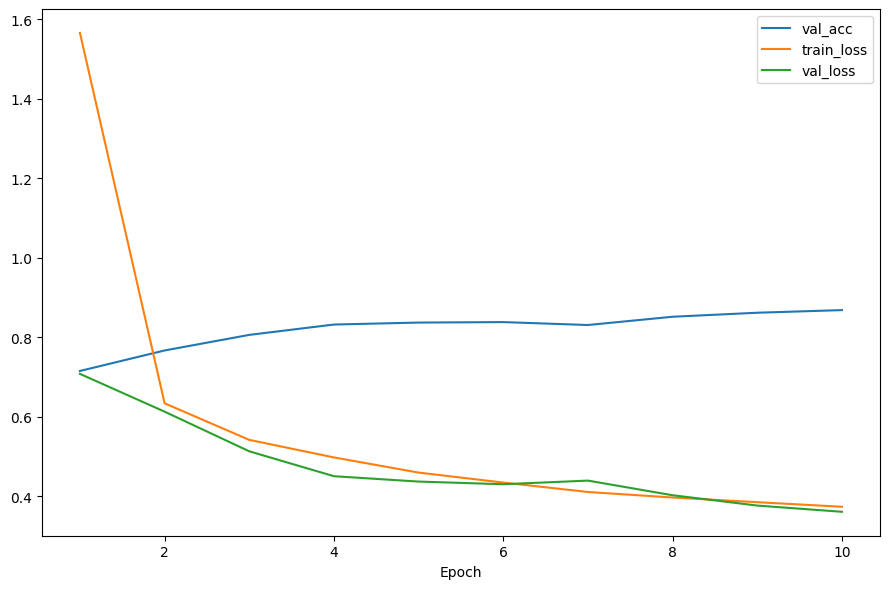

In [5]:
img_size, patch_size = 96, 16
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
model = spy.ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)
trainer = spy.Trainer(max_epochs=10)
data = spy.FashionMNIST(batch_size=128, resize=(img_size, img_size))
trainer.fit(model, data)

Show 3 metrics (training loss, validation loss, validation accuracy) of the last epoch

In [6]:
print(model.board['train_loss'][-1])
print(model.board['val_loss'][-1])
print(model.board['val_acc'][-1])

0.37413446881623663
0.361520950930028
0.8684731012658228


Show predictions of our model

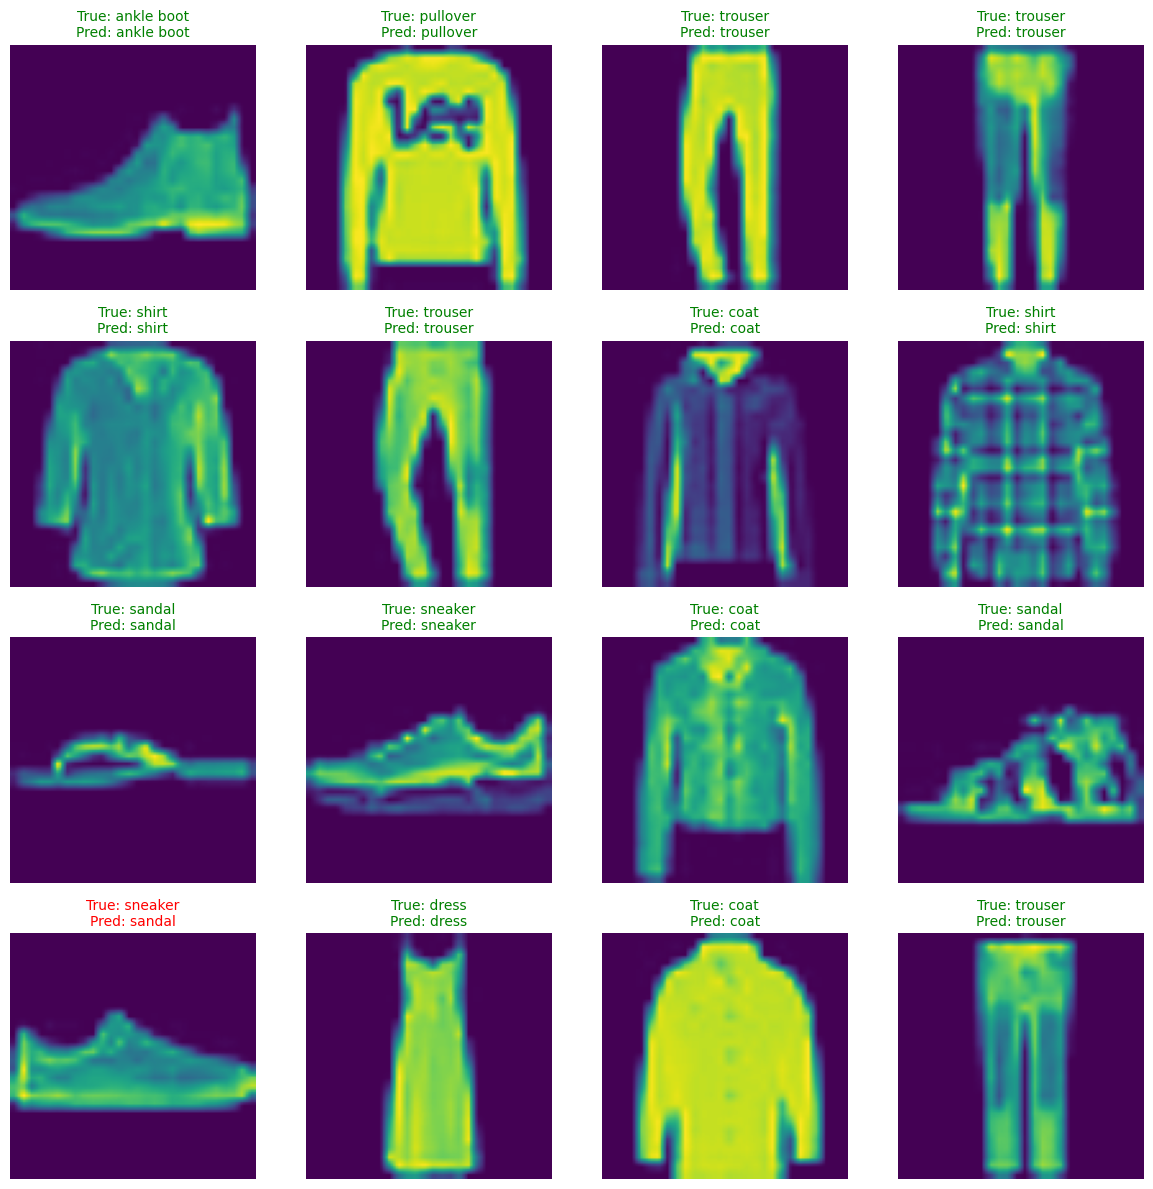

In [8]:
spy.visualize_prediction(model, data, 16, trainer)

### 2.2. Train ViT model on CIFAR10 dataset

The CIFAR-10 dataset consists of 60,000 32x32 colour image in 10 classes, with 6000 per classes
- Training images: 50,000 examples
- Testing images: 10,000 examples

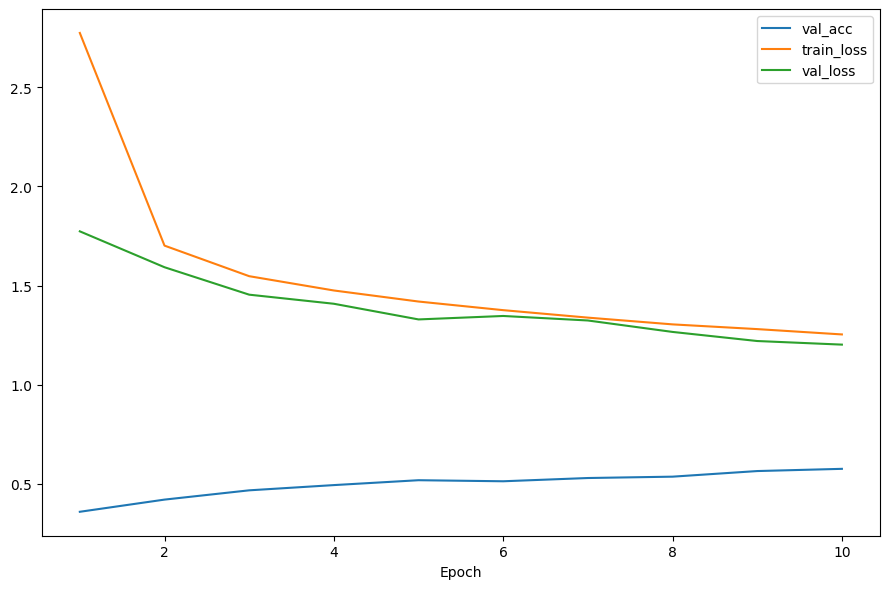

In [9]:
model_CIFAR10 = spy.ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)
trainer = spy.Trainer(max_epochs=10)
data_CIFAR10 = spy.CIFAR10(batch_size=128, resize=(img_size, img_size))
trainer.fit(model_CIFAR10, data_CIFAR10)

Show 3 metrics (training loss, validation loss, validation accuracy) of the last epoch

In [10]:
print(model.board['train_loss'][-1])
print(model.board['val_loss'][-1])
print(model.board['val_acc'][-1])

0.37413446881623663
0.361520950930028
0.8684731012658228


Show predictions of our model

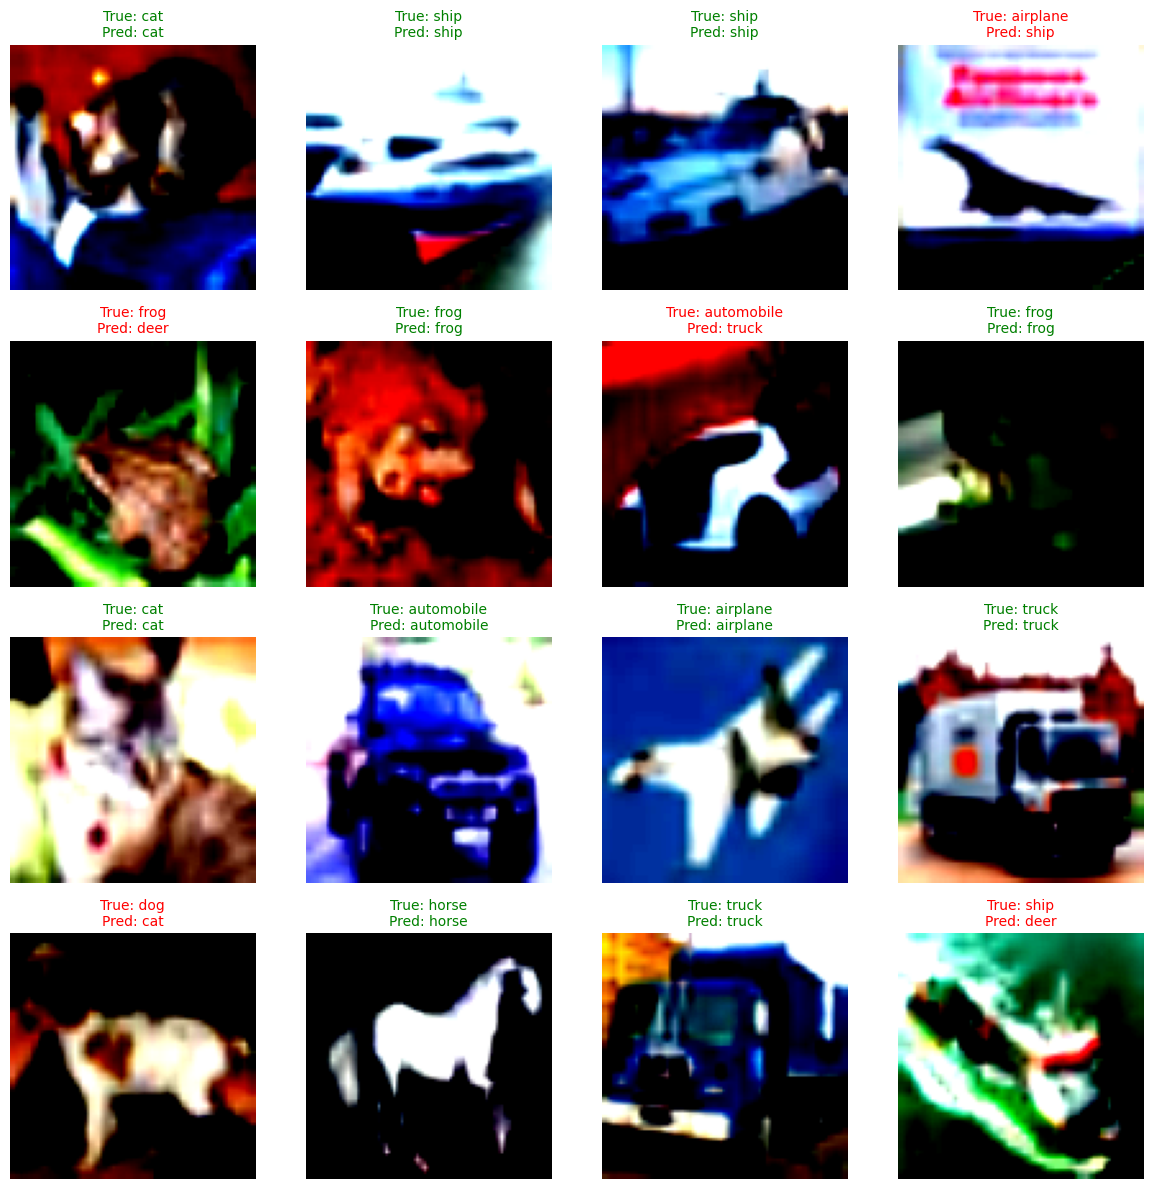

In [12]:
spy.visualize_prediction(model_CIFAR10, data_CIFAR10, 16, trainer)